In [2]:
import pandas as pd
df = pd.read_csv("./phishing_site_urls.csv")
df.head()
df.describe()

,URL,Label
count,549346,549346
unique,507195,2
top,jhomitevd2abj3fk.tor2web.org/,good
freq,52,392924


In [3]:

df.shape # Get the number of columns only

(549346, 2)

In [4]:
df.drop_duplicates(subset ="URL", keep = 'first', inplace=True)
df.describe()
df.info()
df.dropna()

<class 'pandas.DataFrame'>
Index: 507195 entries, 0 to 516470
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   URL     507195 non-null  str  
 1   Label   507195 non-null  str  
dtypes: str(2)
memory usage: 11.6 MB


,URL,Label
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,bad
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,bad
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,bad
3,mail.printakid.com/www.online.americanexpress....,bad
4,thewhiskeydregs.com/wp-content/themes/widescre...,bad
...,...,...
516466,23.227.196.215/,bad
516467,apple-checker.org/,bad
516468,apple-iclods.org/,bad
516469,apple-uptoday.org/,bad


In [5]:
df["len"] = df["URL"].apply(len)
df.head()


,URL,Label,len
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,bad,225
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,bad,81
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,bad,177
3,mail.printakid.com/www.online.americanexpress....,bad,60
4,thewhiskeydregs.com/wp-content/themes/widescre...,bad,116


In [ ]:
from urllib.parse import urlparse
import re
from difflib import SequenceMatcher


def extract_features(url):
    features = {}
    
    try:
        parsed = urlparse(url if url.startswith("http") else "http://" + url)
        domain = parsed.netloc
        path   = parsed.path
        query  = parsed.query
    except:
        parsed = None
        domain = url
        path   = ""
        query  = ""

    
    features["url_length"]    = len(url)
    features["domain_length"] = len(domain)
    features["path_length"]   = len(path)
    features["nb_params"]     = len(query.split("&")) if query else 0

   
    features["nb_dots"]       = url.count(".")
    features["nb_hyphens"]    = url.count("-")
    features["nb_slashes"]    = url.count("/")
    features["nb_at"]         = url.count("@")
    features["nb_digits"]     = sum(c.isdigit() for c in url)
    features["nb_percent"]    = url.count("%")
    features["has_double_slash"] = int("//" in url[7:])  
    features["ratio_digits"]  = features["nb_digits"] / len(url) if len(url) > 0 else 0


    subdomains = domain.split(".")
    features["nb_subdomains"] = max(len(subdomains) - 2, 0)
    features["has_ip"]        = int(bool(re.match(r"\d+\.\d+\.\d+\.\d+", domain)))
    features["has_port"]      = int(":" in domain)

    brands = ["paypal", "google", "apple", "amazon", "microsoft", "facebook"]
    features["has_brand"] = int(any(b in url.lower() for b in brands))

    tld = domain.split(".")[-1].lower()
    features["suspicious_tld"] = int(tld in {"tk", "ml", "ga", "cf", "xyz", "top"})

    features["is_http"] = int(url.startswith("http://"))

    domain_sans_tld = ".".join(domain.split(".")[:-1])  
    features["brand_not_main_domain"] = int(
    any(b in url.lower() for b in brands) and 
    not any(domain_sans_tld == b for b in brands)  
    )
    tld = subdomains[-1] if subdomains else ""

    def ressemble_a_une_marque(domain, seuil=0.85):
        brands = ["paypal", "google", "apple", "amazon", "microsoft", 
              "facebook", "netflix", "instagram", "youtube", "twitter"]
        domain_principal = domain.split(".")[0].lower()
    
        for brand in brands:
            similarite = SequenceMatcher(None, domain_principal, brand).ratio()
            if similarite >= seuil and domain_principal != brand:
                return 1
        return 0

    features["typosquatting"] = ressemble_a_une_marque(domain)  
    return features

feature_df = pd.DataFrame(df["URL"].apply(extract_features).tolist())
df_final   = pd.concat([df.reset_index(drop=True), feature_df], axis=1)


df_final.head()
    
    
    

,URL,Label,len,url_length,domain_length,path_length,nb_params,nb_dots,nb_hyphens,nb_slashes,...,has_double_slash,ratio_digits,nb_subdomains,has_ip,has_port,has_brand,suspicious_tld,is_http,brand_not_main_domain,typosquatting
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,bad,225,225,9,125,4,6,4,10,...,0,0.257778,0,0,0,0,0,0,0,0
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,bad,81,81,15,66,0,5,2,4,...,0,0.012346,1,0,0,1,0,0,1,0
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,bad,177,177,16,161,0,7,1,11,...,0,0.265537,0,0,0,1,0,0,1,0
3,mail.printakid.com/www.online.americanexpress....,bad,60,60,18,42,0,6,0,2,...,0,0.000000,1,0,0,0,0,0,0,0
4,thewhiskeydregs.com/wp-content/themes/widescre...,bad,116,116,19,60,1,1,1,10,...,1,0.181034,0,0,0,0,0,0,0,0


In [ ]:
from collections import Counter
import re

# Découper chaque URL en mots
tous_les_mots = []
for url in df["URL"].str.lower():
    mots = re.split(r'[^a-z]+', url)  #
    mots = [m for m in mots if len(m) > 3]  
    tous_les_mots.extend(mots)

# Compter et afficher les 30 plus fréquents
counter = Counter(tous_les_mots)
for mot, count in counter.most_common(200):
    print(f"{mot}: {count}")

html: 84789
index: 29710
login: 22171
wiki: 17846
wikipedia: 13715
paypal: 11690
aspx: 11306
people: 10634
news: 10337
watch: 9634
battle: 9159
youtube: 8763
facebook: 8606
blogspot: 8092
content: 7881
images: 7328
info: 7149
yahoo: 6606
webscr: 6015
page: 5602
montreal: 5402
amazon: 5351
city: 5300
name: 5093
home: 5083
linkedin: 5068
view: 4903
music: 4827
dispatch: 4823
secure: 4792
article: 4668
pages: 4218
includes: 4168
search: 4097
topic: 4090
sports: 4044
directory: 3924
answers: 3711
imdb: 3498
articles: 3479
admin: 3469
tools: 3461
kansas: 3433
blog: 3417
about: 3379
site: 3303
topics: 3227
ietf: 3224
update: 3210
lyrics: 3096
account: 3057
school: 3021
list: 3014
story: 3008
canada: 2988
myspace: 2936
mylife: 2833
shtml: 2781
online: 2741
football: 2707
rand: 2671
genealogy: 2623
ancestry: 2584
archive: 2532
video: 2522
http: 2489
quebec: 2461
state: 2407
category: 2365
wordpress: 2363
plugins: 2362
artist: 2344
players: 2343
player: 2320
history: 2317
team: 2265
album: 2256

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report

feature_cols = feature_df.columns.tolist()
X = df_final[feature_cols]
y = LabelEncoder().fit_transform(df_final["Label"])  

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#  Modele 1  Logistic Regression (baseline) 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

lr = LogisticRegression(class_weight="balanced", max_iter=1000)
lr.fit(X_train_scaled, y_train)
print("=== Logistic Regression ===")
print(classification_report(y_test, lr.predict(X_test_scaled)))

#  Modele 2 : Random Forest 
rf = RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42)
rf.fit(X_train, y_train)
print("=== Random Forest ===")
print(classification_report(y_test, rf.predict(X_test)))

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.48      0.63      0.55     22860
           1       0.88      0.80      0.84     78579

    accuracy                           0.76    101439
   macro avg       0.68      0.72      0.69    101439
weighted avg       0.79      0.76      0.77    101439

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.76      0.79      0.77     22860
           1       0.94      0.93      0.93     78579

    accuracy                           0.90    101439
   macro avg       0.85      0.86      0.85    101439
weighted avg       0.90      0.90      0.90    101439



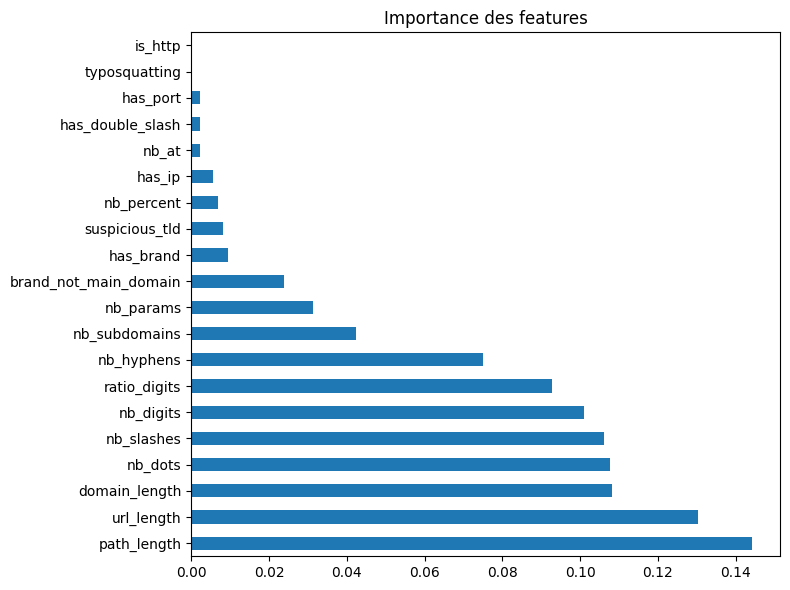

In [67]:
import matplotlib.pyplot as plt

importances = pd.Series(rf.feature_importances_, index=feature_cols)
importances.sort_values(ascending=False).plot(kind="barh", figsize=(8, 6))
plt.title("Importance des features")
plt.tight_layout()
plt.show()

In [ ]:
print(rf.classes_)

import numpy as np
from sklearn.metrics import classification_report

y_proba = rf.predict_proba(X_test)[:, 0]  

for seuil in [0.2, 0.3, 0.4, 0.5]:
    y_pred_seuil = (y_proba >= seuil).astype(int)  
    y_pred_seuil = 1 - y_pred_seuil  
    print(f"\n=== Seuil {seuil} ===")
    print(classification_report(y_test, y_pred_seuil))

    

[0 1]

=== Seuil 0.2 ===
              precision    recall  f1-score   support

           0       0.54      0.91      0.68     22860
           1       0.97      0.78      0.86     78579

    accuracy                           0.81    101439
   macro avg       0.76      0.84      0.77    101439
weighted avg       0.87      0.81      0.82    101439


=== Seuil 0.3 ===
              precision    recall  f1-score   support

           0       0.63      0.87      0.73     22860
           1       0.96      0.85      0.90     78579

    accuracy                           0.86    101439
   macro avg       0.79      0.86      0.82    101439
weighted avg       0.88      0.86      0.86    101439


=== Seuil 0.4 ===
              precision    recall  f1-score   support

           0       0.70      0.83      0.76     22860
           1       0.95      0.90      0.92     78579

    accuracy                           0.88    101439
   macro avg       0.82      0.86      0.84    101439
weighted av

In [72]:
def predire(url, seuil=0.5):
    features = extract_features(url)
    X = pd.DataFrame([features])
    proba_bad = rf.predict_proba(X)[0][0]
    
    if proba_bad >= seuil:
        return "PHISHING"
    else:
        return "LÉGITIME"

# Test
print(predire("https://google.com"))

LÉGITIME
